# Hierarchical emergency classification with DistilBERT-base

Fine-tune two `distilbert-base-uncased` sequence classifiers as a cascade: the first predicts the broad category, then the second predicts a subcategory conditioned on that category. At inference, the second stage is restricted to valid children of the predicted category.

In [1]:
from pathlib import Path

import numpy as np

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
)

from classification_utils import (
    category_to_id,
    subcategory_to_id,
    create_training_arguments,
    display_classification_analytics,
    load_labeled_csv,
    score_bert_class_probabilities,
    seed_everything,
    stratified_split,
    tokenize_bert_dataset,
    trainer_compute_metrics,
)

In [2]:
SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

seed_everything(SEED)

In [3]:
category_names = [
    name for name, _ in sorted(category_to_id.items(), key=lambda item: item[1])
]
id_to_category = dict(enumerate(category_names))

data = load_labeled_csv(
    Path("disaster_messages.csv"),
    text_column="message",
    label_column="category",
    label_to_id=category_to_id,
    encoded_label_column="category_labels",
)
unknown_subcategories = sorted(set(data["subcategory"]) - set(subcategory_to_id))
if unknown_subcategories:
    raise ValueError(f"Unknown subcategories: {unknown_subcategories}")

data["subcategory_path"] = data["category"] + "/" + data["subcategory"]
subcategory_names = sorted(data["subcategory_path"].unique())
subcategory_path_to_id = {
    name: label_id for label_id, name in enumerate(subcategory_names)
}
id_to_subcategory_path = dict(enumerate(subcategory_names))
data["subcategory_labels"] = (
    data["subcategory_path"].map(subcategory_path_to_id).astype(int)
)

subcategory_paths_by_category = {
    category: [
        f"{category}/{subcategory}"
        for subcategory in sorted(
            group["subcategory"].unique(), key=subcategory_to_id.get
        )
    ]
    for category, group in data.groupby("category")
}
train_df, validation_df, test_df = stratified_split(
    data[[
        "message", "category", "subcategory", "subcategory_path",
        "category_labels", "subcategory_labels",
    ]],
    label_column="subcategory_labels",
    seed=SEED,
)
print(f"train={len(train_df):,}, validation={len(validation_df):,}, test={len(test_df):,}")
data.groupby(["category", "subcategory"]).size()

train=7,000, validation=1,500, test=1,500


category               subcategory    
evacuation             mandatory          516
                       voluntary          458
fire                   structural_fire    345
                       vehicle_fire       335
                       wildfire           369
flooding               flash_flood        328
                       house_flooding     378
                       street_flooding    345
infrastructure_damage  bridge             224
                       other              261
                       road               242
                       utility            239
medical                heavy_bleeding     203
                       illness            199
                       injury             183
                       light_bleeding     200
                       unconscious        201
missing_person         adult              331
                       child              305
                       elderly            346
structure_damage       light             

## Prepare both stages

Stage 1 maps the raw message to a category. Stage 2 receives both the category and message, and maps them to a globally unique `category/subcategory` label. During training, stage 2 uses the true category; during evaluation and prediction, it uses stage 1's prediction.

In [4]:
def make_category_frame(frame):
    return frame[["message", "category_labels"]].rename(
        columns={"category_labels": "labels"}
    )

def make_subcategory_frame(frame, categories=None):
    result = frame.copy()
    if categories is not None:
        result["category"] = list(categories)
    result["message"] = (
        "category: " + result["category"] + " message: " + result["message"]
    )
    return result[["message", "subcategory_labels"]].rename(
        columns={"subcategory_labels": "labels"}
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
category_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(category_names),
    id2label=id_to_category,
    label2id=category_to_id,
)
subcategory_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(subcategory_names),
    id2label=id_to_subcategory_path,
    label2id=subcategory_path_to_id,
)

category_train_dataset = tokenize_bert_dataset(
    tokenizer, make_category_frame(train_df), max_length=MAX_LENGTH
)
category_validation_dataset = tokenize_bert_dataset(
    tokenizer, make_category_frame(validation_df), max_length=MAX_LENGTH
)
subcategory_train_dataset = tokenize_bert_dataset(
    tokenizer, make_subcategory_frame(train_df), max_length=MAX_LENGTH
)
subcategory_validation_dataset = tokenize_bert_dataset(
    tokenizer, make_subcategory_frame(validation_df), max_length=MAX_LENGTH
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
category_train_dataset, subcategory_train_dataset

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

(Dataset({
     features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 7000
 }),
 Dataset({
     features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 7000
 }))

## Fine-tune category first, then subcategory

In [5]:
category_training_arguments = create_training_arguments(
    output_dir="results/distilbert_base_category",
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=32,
    gradient_accumulation_steps=1
)
category_trainer = Trainer(
    model=category_model,
    args=category_training_arguments,
    train_dataset=category_train_dataset,
    eval_dataset=category_validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
category_trainer.train()

subcategory_training_arguments = create_training_arguments(
    output_dir="results/distilbert_base_subcategory",
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=32,
    gradient_accumulation_steps=1
)
subcategory_trainer = Trainer(
    model=subcategory_model,
    args=subcategory_training_arguments,
    train_dataset=subcategory_train_dataset,
    eval_dataset=subcategory_validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
subcategory_trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.010028
2,0.481285,0.003073
3,0.006458,0.002265


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,No log,0.631658
2,1.689537,0.094904
3,0.250825,0.046076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1314, training_loss=0.7566806584188382, metrics={'train_runtime': 193.2458, 'train_samples_per_second': 108.67, 'train_steps_per_second': 6.8, 'total_flos': 183430021934448.0, 'train_loss': 0.7566806584188382, 'epoch': 3.0})

## Evaluate the cascade

First evaluate broad-category classification. Then condition the second classifier on each predicted category and mask its output to valid children. The subcategory metrics therefore include error propagation from stage 1 and match production inference.

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000

                       precision    recall  f1-score   support

              medical       1.00      1.00      1.00       148
     structure_damage       1.00      1.00      1.00       150
              utility       1.00      1.00      1.00       156
       missing_person       1.00      1.00      1.00       148
       supply_request       1.00      1.00      1.00       150
             flooding       1.00      1.00      1.00       157
              trapped       1.00      1.00      1.00       143
                 fire       1.00      1.00      1.00       157
infrastructure_damage       1.00      1.00      1.00       146
           evacuation       1.00      1.00      1.00       145

             accuracy                           1.00      1500
            macro avg       1.00      1.00      1.00      1500
         weighted avg       1.00      1.00      1.00      1500

ROC AUC: 1.0000


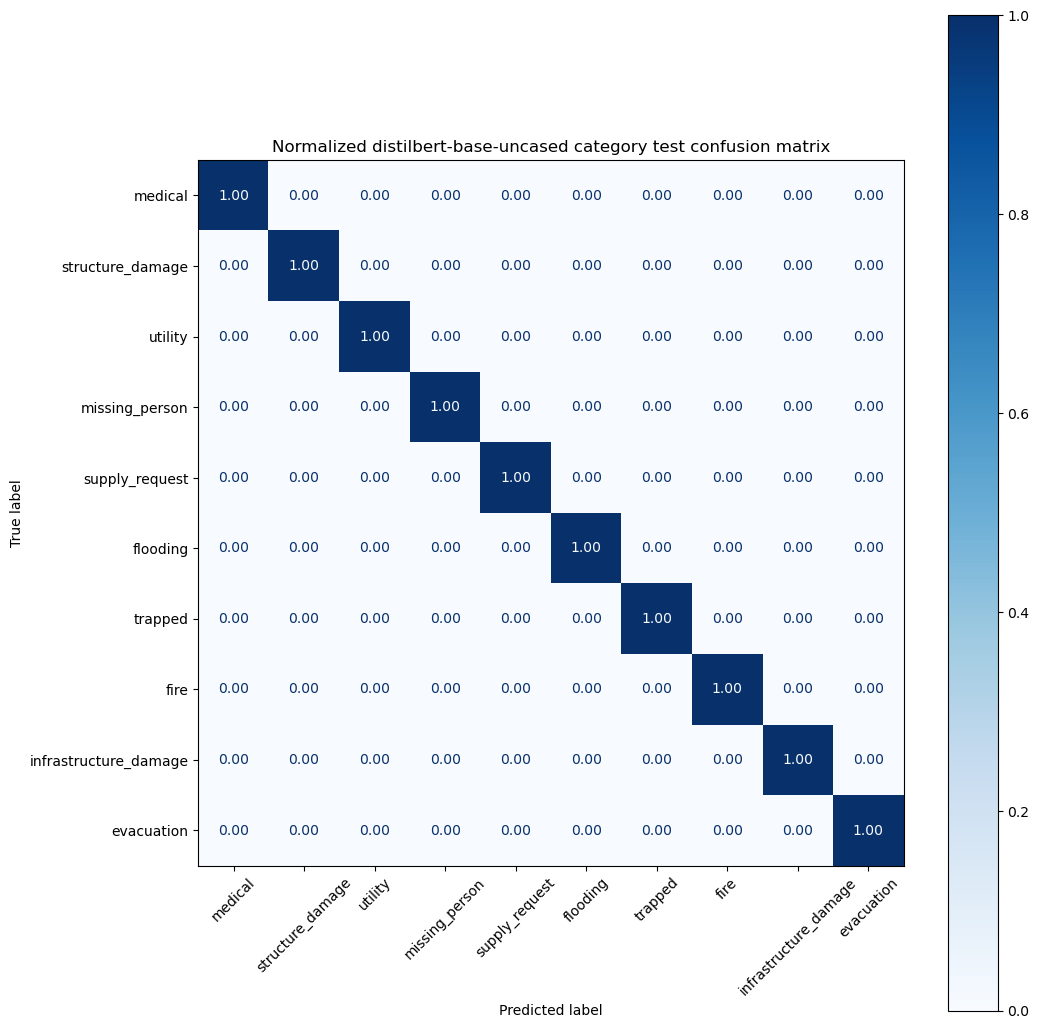

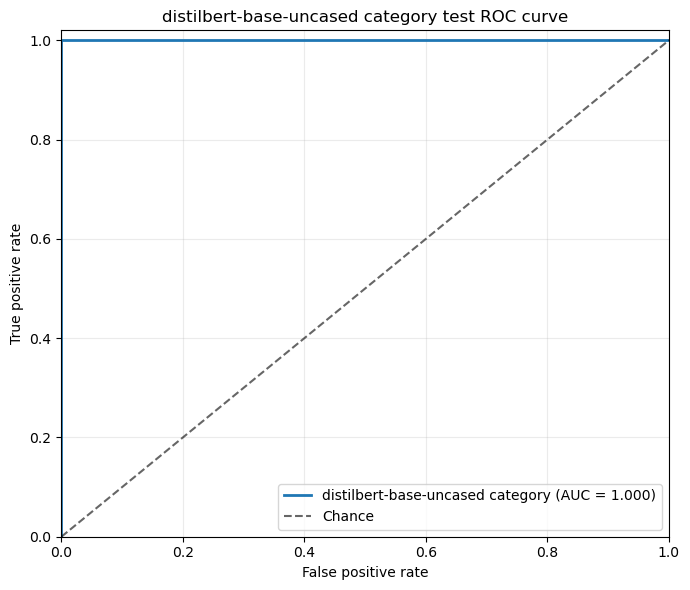

In [6]:
category_probabilities = score_bert_class_probabilities(
    category_trainer.model,
    tokenizer,
    test_df["message"].tolist(),
    max_length=MAX_LENGTH,
)
predicted_category_ids = category_probabilities.argmax(axis=1)
predicted_categories = [
    category_names[label_id] for label_id in predicted_category_ids
]

category_analytics = display_classification_analytics(
    test_df["category_labels"].to_numpy(),
    category_names,
    probabilities=category_probabilities,
    model_name=MODEL_NAME + " category",
)

Accuracy: 0.9980
Macro Precision: 0.9975
Macro Recall: 0.9973
Macro F1: 0.9974

                               precision    recall  f1-score   support

         evacuation/mandatory       1.00      1.00      1.00        77
         evacuation/voluntary       1.00      1.00      1.00        68
         fire/structural_fire       1.00      1.00      1.00        51
            fire/vehicle_fire       1.00      1.00      1.00        51
                fire/wildfire       1.00      1.00      1.00        55
         flooding/flash_flood       1.00      1.00      1.00        49
      flooding/house_flooding       1.00      1.00      1.00        57
     flooding/street_flooding       1.00      1.00      1.00        51
 infrastructure_damage/bridge       1.00      1.00      1.00        34
  infrastructure_damage/other       0.97      1.00      0.99        39
   infrastructure_damage/road       1.00      1.00      1.00        37
infrastructure_damage/utility       1.00      0.97      0.99       

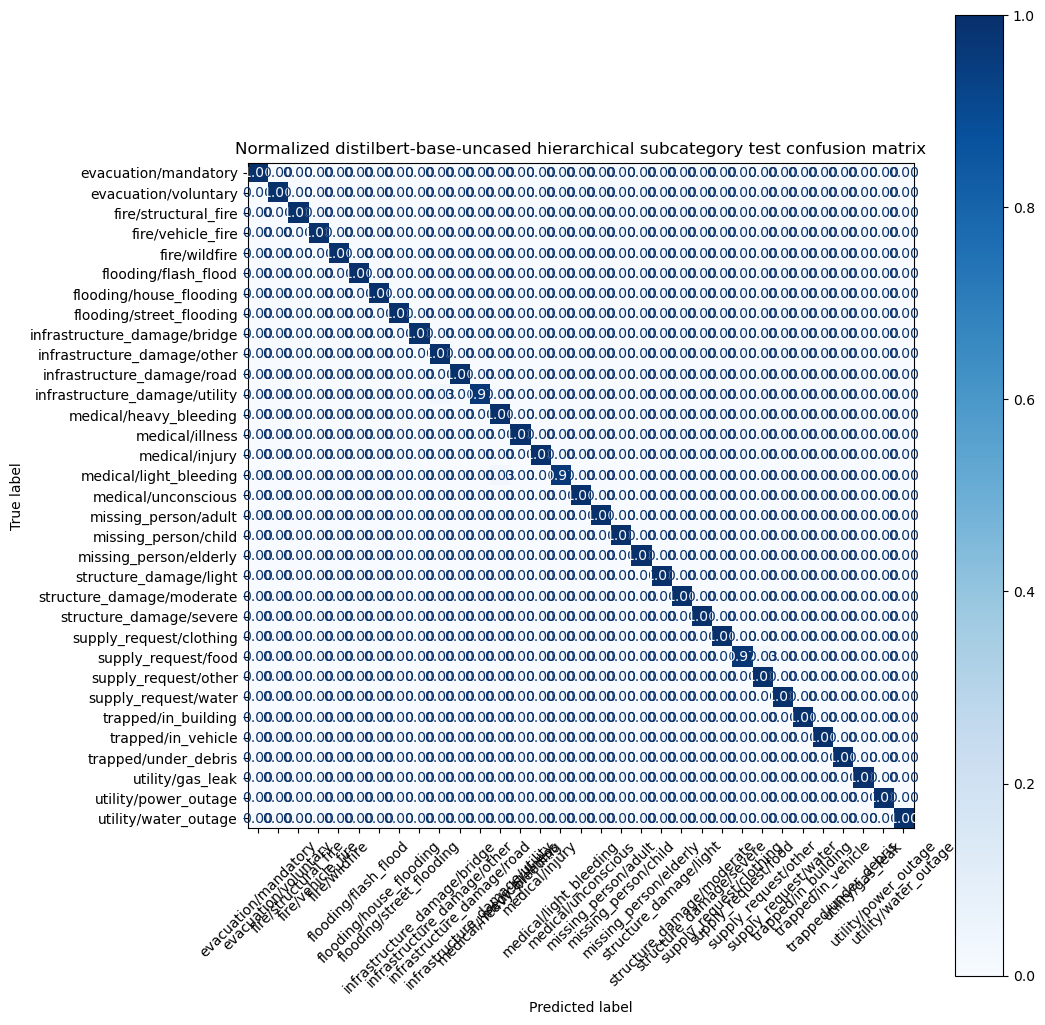

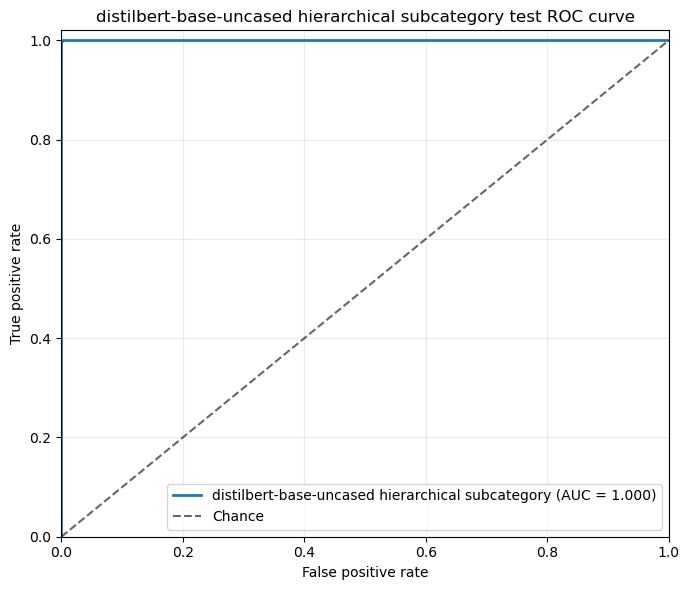

In [7]:
stage_two_frame = make_subcategory_frame(test_df, predicted_categories)
raw_subcategory_probabilities = score_bert_class_probabilities(
    subcategory_trainer.model,
    tokenizer,
    stage_two_frame["message"].tolist(),
    max_length=MAX_LENGTH,
)
subcategory_probabilities = np.zeros_like(raw_subcategory_probabilities)

for row_id, category in enumerate(predicted_categories):
    allowed_columns = [
        subcategory_path_to_id[path]
        for path in subcategory_paths_by_category[category]
    ]
    allowed_scores = raw_subcategory_probabilities[row_id, allowed_columns]
    subcategory_probabilities[row_id, allowed_columns] = (
        allowed_scores / allowed_scores.sum()
    )

subcategory_analytics = display_classification_analytics(
    test_df["subcategory_labels"].to_numpy(),
    subcategory_names,
    probabilities=subcategory_probabilities,
    model_name=MODEL_NAME + " hierarchical subcategory",
)

## Save and predict

In [8]:
category_model_path = Path("models/distilbert_base_category")
subcategory_model_path = Path("models/distilbert_base_subcategory")
category_trainer.save_model(category_model_path)
subcategory_trainer.save_model(subcategory_model_path)
tokenizer.save_pretrained(category_model_path)
tokenizer.save_pretrained(subcategory_model_path)

def predict_emergency(text):
    category_scores = score_bert_class_probabilities(
        category_trainer.model, tokenizer, [text], max_length=MAX_LENGTH
    )[0]
    category_id = int(category_scores.argmax())
    category = category_names[category_id]

    stage_two_text = f"category: {category} message: {text}"
    raw_subcategory_scores = score_bert_class_probabilities(
        subcategory_trainer.model, tokenizer, [stage_two_text], max_length=MAX_LENGTH
    )[0]
    allowed_paths = subcategory_paths_by_category[category]
    allowed_columns = [subcategory_path_to_id[path] for path in allowed_paths]
    allowed_scores = raw_subcategory_scores[allowed_columns]
    allowed_scores = allowed_scores / allowed_scores.sum()
    local_subcategory_id = int(allowed_scores.argmax())
    subcategory_path = allowed_paths[local_subcategory_id]

    return {
        "category": category,
        "category_confidence": float(category_scores[category_id]),
        "subcategory": subcategory_path.split("/", 1)[1],
        "subcategory_confidence_given_category": float(
            allowed_scores[local_subcategory_id]
        ),
    }

for message in ["fire in building", "send an ambulance", "we are trapped"]:
    print(f"{message!r} -> {predict_emergency(message)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

'fire in building' -> {'category': 'fire', 'category_confidence': 0.9972098469734192, 'subcategory': 'structural_fire', 'subcategory_confidence_given_category': 0.9916553497314453}
'send an ambulance' -> {'category': 'trapped', 'category_confidence': 0.5067808032035828, 'subcategory': 'in_building', 'subcategory_confidence_given_category': 0.6322324872016907}
'we are trapped' -> {'category': 'trapped', 'category_confidence': 0.9936736822128296, 'subcategory': 'in_building', 'subcategory_confidence_given_category': 0.9855064749717712}
